In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

from sklearn.model_selection import cross_val_score, GridSearchCV

import joblib

In [2]:
df=pd.read_csv("https://github.com/YBIFoundation/Dataset/raw/main/TelecomCustomerChurn.csv")
df.head(10)
df.shape

(7043, 21)

In [3]:
df.columns

Index(['customerID', 'Gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'Tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   Gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   Tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.describe()

,SeniorCitizen,Tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
df.isnull().sum()

customerID          0
Gender              0
SeniorCitizen       0
Partner             0
Dependents          0
Tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
missing=df.isnull().sum()/len(df)*100
missing.sort_values(ascending=False)

customerID          0.0
Gender              0.0
SeniorCitizen       0.0
Partner             0.0
Dependents          0.0
Tenure              0.0
PhoneService        0.0
MultipleLines       0.0
InternetService     0.0
OnlineSecurity      0.0
OnlineBackup        0.0
DeviceProtection    0.0
TechSupport         0.0
StreamingTV         0.0
StreamingMovies     0.0
Contract            0.0
PaperlessBilling    0.0
PaymentMethod       0.0
MonthlyCharges      0.0
TotalCharges        0.0
Churn               0.0
dtype: float64

In [8]:
df["TotalCharges"]=pd.to_numeric(
    df['TotalCharges'],errors='coerce'
)

In [9]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [10]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
7038    False
7039    False
7040    False
7041    False
7042    False
Length: 7043, dtype: bool

In [11]:
df=df.drop('customerID',axis=1)

In [12]:
df['Churn']=df['Churn'].map({"Yes":1, "No":0})

In [13]:
df["Churn"].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [14]:
df["Churn"].value_counts(normalize=True) * 100

Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64

In [15]:
df.columns

Index(['Gender', 'SeniorCitizen', 'Partner', 'Dependents', 'Tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

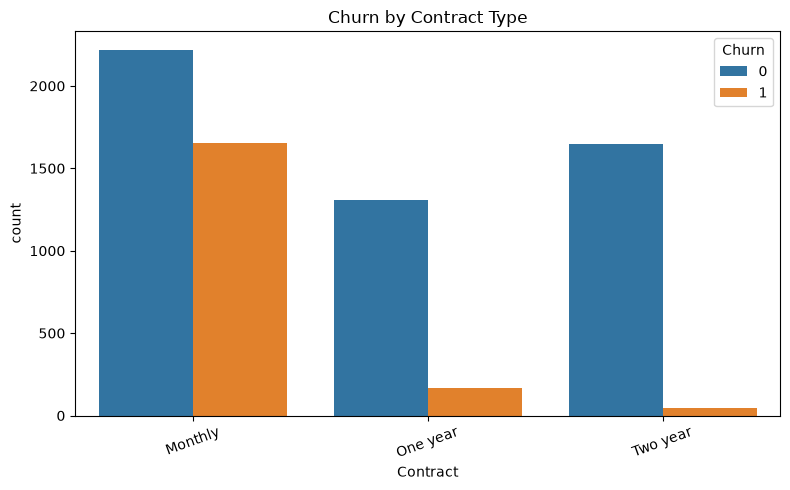

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(
    data=df,
    x="Contract",
    hue="Churn",
    ax=ax
)

ax.set_title("Churn by Contract Type")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

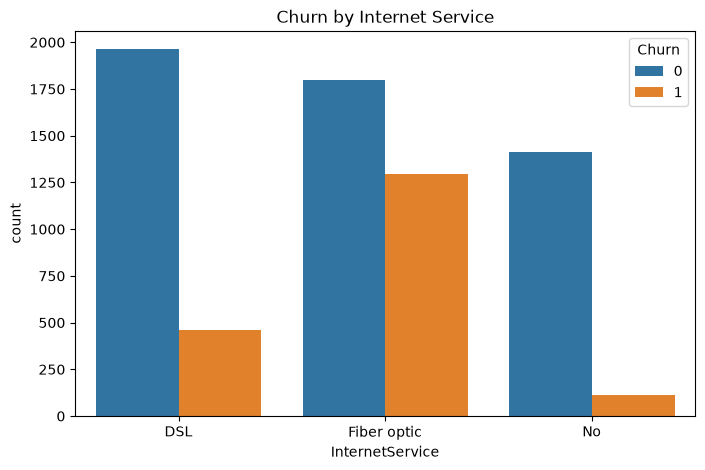

In [17]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="InternetService",
    hue="Churn",
    data=df
)

plt.title("Churn by Internet Service")

plt.show()

In [18]:
df.columns

Index(['Gender', 'SeniorCitizen', 'Partner', 'Dependents', 'Tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

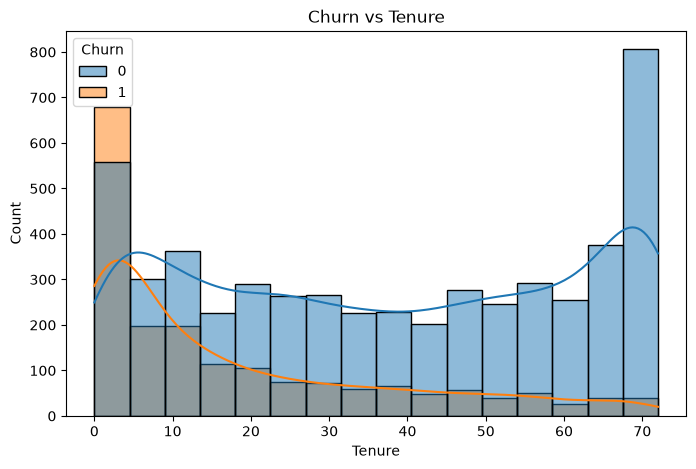

In [19]:
# Churn vs tenure
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Tenure",
    hue="Churn",
    kde=True
)

plt.title("Churn vs Tenure")

plt.show()

In [20]:
df["Tenure_group"] = pd.cut(
    df["Tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=[
        "0-1 Year",
        "1-2 Years",
        "2-4 Years",
        "4+ Years"
    ]
)

In [21]:
df["average_monthly_spending"] = (
    df["TotalCharges"] /
    df["Tenure"].replace(0, 1)
)

In [22]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

In [23]:
y.shape

(7043,)

In [24]:
# select numeric and catogorical vallue
numeric_feature=X.select_dtypes( include=['int64', 'float']).columns

categorical_feature = X.select_dtypes(include=['object', 'category']).columns

In [25]:
print('Numrical:----------')
print(numeric_feature)

print('Categorical:---------')
print(categorical_feature)

Numrical:----------
Index(['SeniorCitizen', 'Tenure', 'MonthlyCharges', 'TotalCharges',
       'average_monthly_spending'],
      dtype='object')
Categorical:---------
Index(['Gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Tenure_group'],
      dtype='object')


In [26]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [27]:
# preprocessing pipline
# ONE HOT ENCODING FOR CAREGORICAL COLUMNDS
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

In [28]:
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [29]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_feature
        ),
        (
            "cat",
            categorical_transformer,
            categorical_feature
        )
    ]
)

In [30]:
lr_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000
            )
        )
    ]
)

In [31]:
lr_model.fit(
    x_train,
    y_train
)

c:\Users\yadav\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](21,)","['Gender','SeniorCitizen','Partner',...,'TotalCharges','Tenure_group', 'average_monthly_spending']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,21
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying `

In [32]:
lr_pred = lr_model.predict(x_test)

In [33]:
dt_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                max_depth=5,
                random_state=42
            )
        )
    ]
)

In [34]:
dt_model.fit(x_train, y_train)

dt_pred = dt_model.predict(x_test)

In [35]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42
            )
        )
    ]
)

In [36]:
rf_model.fit(x_train, y_train)

rf_pred = rf_model.predict(x_test)

In [37]:
gb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            GradientBoostingClassifier(
                n_estimators=100,
                learning_rate=0.1,
                max_depth=3,
                random_state=42
            )
        )
    ]
)

In [38]:
gb_model.fit(
    x_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](21,)","['Gender','SeniorCitizen','Partner',...,'TotalCharges','Tenure_group', 'average_monthly_spending']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,21
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying `

In [39]:
gb_pred = gb_model.predict(x_test)

In [40]:
gb_probability = gb_model.predict_proba(x_test)[:, 1]

In [41]:
# Compare all model
def evaluate_model(model, x_test, y_test):

    predictions = model.predict(x_test)

    probabilities = model.predict_proba(x_test)[:, 1]

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions
    )

    recall = recall_score(
        y_test,
        predictions
    )

    f1 = f1_score(
        y_test,
        predictions
    )

    roc_auc = roc_auc_score(
        y_test,
        probabilities
    )

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    }

In [42]:
results = {}

results["Logistic Regression"] = evaluate_model(
    lr_model,
    x_test,
    y_test
)

results["Decision Tree"] = evaluate_model(
    dt_model,
    x_test,
    y_test
)

results["Random Forest"] = evaluate_model(
    rf_model,
    x_test,
    y_test
)

results["Gradient Boosting"] = evaluate_model(
    gb_model,
    x_test,
    y_test
)

In [43]:
results_df = pd.DataFrame(results).T

results_df

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Logistic Regression,0.794180,0.640940,0.510695,0.568452,0.841233
Decision Tree,0.791341,0.602041,0.631016,0.616188,0.834909
Random Forest,0.784244,0.620690,0.481283,0.542169,0.822743
Gradient Boosting,0.799858,0.659722,0.508021,0.574018,0.842203


In [ ]:
cv_scores = cross_val_score(
    gb_model,
    X,
    y,
    cv=5,
    scoring="roc_auc"
)

In [ ]:
print(cv_scores)

[0.85624532 0.85505955 0.82859154 0.83859424 0.84294676]


In [ ]:
print(
    "Mean ROC-AUC:",
    cv_scores.mean()
)

Mean ROC-AUC: 0.8442874820476837


In [ ]:
print(
    "Std:",
    cv_scores.std()
)

Std: 0.01038845764458947


In [ ]:
param_grid = {
    "classifier__n_estimators": [
        100,
        200
    ],

    "classifier__learning_rate": [
        0.05,
        0.1
    ],

    "classifier__max_depth": [
        2,
        3,
        4
    ],

    "classifier__min_samples_split": [
        2,
        5
    ]
}

In [ ]:
grid_search = GridSearchCV(
    gb_model,
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

In [ ]:
grid_search.fit(
    x_train,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__learning_rate': [0.05, 0.1], 'classifier__max_depth': [2, 3, ...], 'classifier__min_samples_split': [2, 5], 'classifier__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20

In [ ]:
grid_search.best_params_

{'classifier__learning_rate': 0.05,
 'classifier__max_depth': 2,
 'classifier__min_samples_split': 2,
 'classifier__n_estimators': 200}

In [ ]:
best_gb_model = grid_search.best_estimator_

In [ ]:
final_pred = best_gb_model.predict(
    x_test
)

In [ ]:
final_probability = (
    best_gb_model.predict_proba(x_test)[:, 1]
)

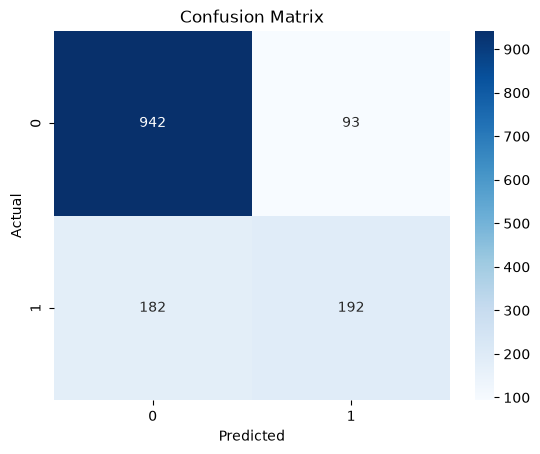

In [ ]:
cm = confusion_matrix(
    y_test,
    final_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
print(
    classification_report(
        y_test,
        final_pred
    )
)

              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.51      0.58       374

    accuracy                           0.80      1409
   macro avg       0.76      0.71      0.73      1409
weighted avg       0.79      0.80      0.80      1409



In [ ]:
roc_auc = roc_auc_score(
    y_test,
    final_probability
)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.845339585109406


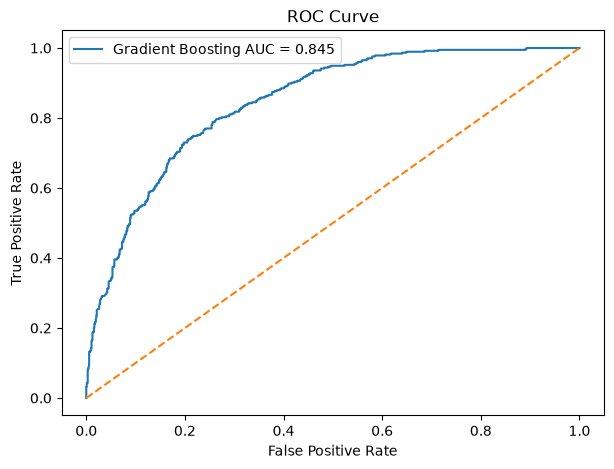

In [ ]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    final_probability
)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"Gradient Boosting AUC = {roc_auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [ ]:
gb_classifier = (
    best_gb_model
    .named_steps["classifier"]
)

In [ ]:
feature_names = (
    best_gb_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

In [ ]:
importance = gb_classifier.feature_importances_

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

In [ ]:
feature_importance = (
    feature_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
)

In [ ]:
feature_importance.head(15)

,Feature,Importance
30,cat__Contract_Monthly,0.406977
1,num__Tenure,0.190810
16,cat__InternetService_Fiber optic,0.169489
17,cat__InternetService_No,0.060383
4,num__average_monthly_spending,0.025209
2,num__MonthlyCharges,0.022058
3,num__TotalCharges,0.020204
33,cat__PaperlessBilling_No,0.015165
37,cat__PaymentMethod_Manual,0.011173
34,cat__PaperlessBilling_Yes,0.009107


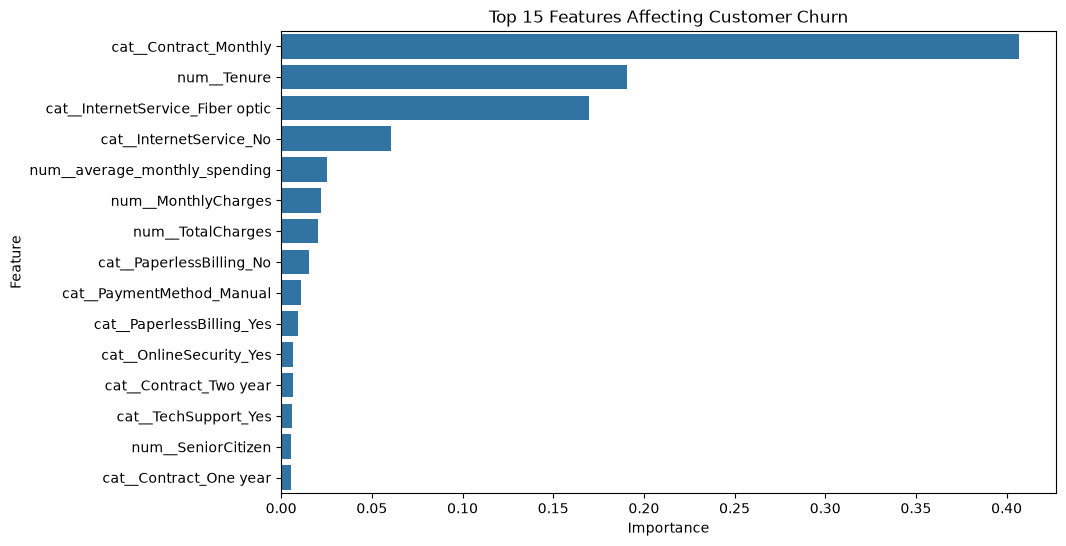

In [ ]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 15 Features Affecting Customer Churn"
)

plt.show()

In [ ]:
customer_results = x_test.copy()

customer_results["Actual_Churn"] = y_test.values

customer_results["Churn_Probability"] = (
    final_probability
)

customer_results["Predicted_Churn"] = (
    final_pred
)

In [ ]:
customer_results.sort_values(
    "Churn_Probability",
    ascending=False
).head(10)

,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Tenure_group,average_monthly_spending,Actual_Churn,Churn_Probability,Predicted_Churn
3380,Male,1,Yes,No,1,Yes,Yes,Fiber optic,No,No,...,Monthly,Yes,Manual,95.10,95.10,0-1 Year,95.10,1,0.911367,1
6866,Male,0,No,No,1,Yes,Yes,Fiber optic,No,No,...,Monthly,Yes,Manual,95.45,95.45,0-1 Year,95.45,1,0.893790,1
4585,Female,1,No,No,1,Yes,Yes,Fiber optic,No,No,...,Monthly,Yes,Manual,85.05,85.05,0-1 Year,85.05,1,0.878484,1
6748,Female,1,No,No,1,Yes,No,Fiber optic,No,No,...,Monthly,Yes,Manual,85.00,85.00,0-1 Year,85.00,1,0.864123,1
2246,Female,0,Yes,Yes,1,Yes,Yes,Fiber optic,Yes,No,...,Monthly,Yes,Manual,102.45,102.45,0-1 Year,102.45,1,0.858399,1
2753,Female,0,No,No,1,Yes,Yes,Fiber optic,No,No,...,Monthly,No,Manual,95.65,95.65,0-1 Year,95.65,1,0.855803,1
6623,Male,1,No,No,1,Yes,Yes,Fiber optic,No,No,...,Monthly,Yes,Manual,76.45,76.45,0-1 Year,76.45,1,0.854911,1
383,Male,0,No,No,1,Yes,Yes,Fiber optic,No,Yes,...,Monthly,Yes,Credit card (automatic),90.85,90.85,0-1 Year,90.85,1,0.850527,1
642,Male,0,No,No,1,Yes,No,Fiber optic,No,No,...,Monthly,Yes,Manual,89.55,89.55,0-1 Year,89.55,1,0.848140,1
2397,Male,0,No,No,1,Yes,No,Fiber optic,No,No,...,Monthly,Yes,Manual,88.35,88.35,0-1 Year,88.35,1,0.844616,1


In [ ]:
def risk_category(probability):

    if probability >= 0.70:
        return "High Risk"

    elif probability >= 0.40:
        return "Medium Risk"

    else:
        return "Low Risk"

In [ ]:
customer_results["Risk"] = (
    customer_results["Churn_Probability"]
    .apply(risk_category)
)

In [ ]:
def recommendation(row):

    if row["Risk"] == "High Risk":

        return (
            "Offer discount + long-term contract "
            "+ dedicated support"
        )

    elif row["Risk"] == "Medium Risk":

        return (
            "Offer personalized plan "
            "and service support"
        )

    else:

        return (
            "Continue regular engagement"
        )

In [ ]:
customer_results["Recommendation"] = (
    customer_results.apply(
        recommendation,
        axis=1
    )
)

In [ ]:
from pathlib import Path

model_path = Path("../models/gradient_boosting_model.pkl")
model_path.parent.mkdir(parents=True, exist_ok=True)

joblib.dump(best_gb_model, model_path)

['..\\models\\gradient_boosting_model.pkl']

In [ ]:
model = joblib.load(
    "../models/gradient_boosting_model.pkl"
)